#Data Təmizləmə və Kəşfiyyat Analizi (EDA)

**Dataset:** Bakı daşınmaz əmlak satış elanları (Bina.az tipli struktur, ''sehriyarmemmedli/binaaz-sale-project'')



In [4]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)


## 1) Data yükləmə və ilkin baxış


In [5]:
pip install kagglehub[pandas-datasets]

In [6]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub


# Load the latest version
path= kagglehub.dataset_download("sehriyarmemmedli/binaaz-sale-project")
print(path)

100%|██████████| 39.8M/39.8M [00:01<00:00, 32.4MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/sehriyarmemmedli/binaaz-sale-project/versions/1


In [7]:
import os
files = os.listdir(path)
print(files)


['house_sale.csv']


In [8]:

file_path = os.path.join(path, 'house_sale.csv')
df= pd.read_csv(file_path, low_memory=False)

In [9]:
df.shape

(100775, 51)

In [10]:
df.head(3)

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,...,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,...,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,...,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,...,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.


Checkpoint 1: forma, tiplər, boş dəyərlər, dublikatlar

In [11]:
df.dtypes

,0
id_x,object
rel_url,object
estate_rel_url_x,object
datetime_scrape_x,object
price,float64
currency_x,object
location,object
attributes,object
city_when,object
city,object


In [12]:
df.head(1)

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,...,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,...,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.


In [13]:
df.isnull().sum().sort_values(ascending=False)

,0
Binanın növü,100621
featured,97626
vip,92179
Torpaq sahəsi,85204
hour_y,85144
İpoteka,67836
mortgage,67836
shop_title,28757
shop_name,28757
products_label,28145


In [14]:
(df.isnull().mean() * 100).round(2).sort_values(ascending=False)

,0
Binanın növü,99.85
featured,96.88
vip,91.47
Torpaq sahəsi,84.55
hour_y,84.49
İpoteka,67.31
mortgage,67.31
shop_title,28.54
shop_name,28.54
products_label,27.93


60-70 faizden cox olan nullari doldurmaq yersizdir.Lakin mumkunleri doldurub qeyri mumkunlere ferqli yanasacagiq

In [15]:
df['featured'].sort_values()

,featured
0,featured
44710,featured
44785,featured
44884,featured
45241,featured
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


In [16]:
# NaN dəyərləri 'not featured' olaraq dolduraq
df['featured'] = df['featured'].fillna('not featured')

In [17]:
df['Binanın növü'].sort_values()

,Binanın növü
52542,Biznes mərkəzi
61022,Biznes mərkəzi
60693,Biznes mərkəzi
59215,Biznes mərkəzi
58625,Biznes mərkəzi
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


In [18]:
# NaN dəyərləri 'diger' olaraq doldurmaq
df['Binanın növü'] = df['Binanın növü'].fillna('diger')

In [19]:
df['vip'].sort_values()

,vip
0,vipped
46699,vipped
46653,vipped
46595,vipped
46591,vipped
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


In [20]:
# NaN dəyərləri 'not vipped' olaraq doldurmaq
df['vip'] = df['vip'].fillna('not vipped')

In [21]:
df['Torpaq sahəsi'].sort_values()

,Torpaq sahəsi
62482,0.1 sot
90016,0.1 sot
50945,0.1 sot
80348,0.1 sot
34608,0.1 sot
...,...
100767,NaN
100768,NaN
100769,NaN
100773,NaN


In [22]:
df.drop('Torpaq sahəsi', axis=1, inplace=True)

In [23]:
df['hour_y'].sort_values()

,hour_y
8849,00:00
8848,00:02
14171,00:03
25835,00:03
25836,00:03
...,...
100770,NaN
100771,NaN
100772,NaN
100773,NaN


In [24]:
df.drop('hour_y', axis=1, inplace=True)

In [25]:
df['mortgage'].value_counts()

,count
mortgage,
İpoteka var,32939


In [26]:
# NaN dəyərləri 'Ipoteka yoxdur' olaraq doldurmaq
df['mortgage'] = df['mortgage'].fillna('Ipoteka yoxdur')

In [27]:
df['İpoteka'].value_counts()

,count
İpoteka,
var,32939


In [28]:
# NaN dəyərləri 'yox' olaraq doldurmaq
df['İpoteka'] = df['İpoteka'].fillna('yox')

In [29]:
df['shop_name'].value_counts()

,count
shop_name,
Real Əmlak Yeni Yasamal,2482
"EVA Group ""Röyal Əmlak""",1936
Real Əmlak Nərimanov,1514
My Dom,1470
"EVA Group ""Platin Real Estate""",1376
...,...
Al Əmlak,1
House Club,1
F&M Club,1


In [30]:
df['shop_name']=df['shop_name'].fillna(df['shop_name'].mode()[0])

In [31]:
df['shop_title'].value_counts()

,count
shop_title,
Daşınmaz əmlak agentliyi,72018


In [32]:
df['shop_title']=df['shop_title'].fillna('Diger Agentlikler')

In [33]:
df['products_label'].value_counts()

,count
products_label,
Agentlik,71981
Kompleks,649


In [34]:
df['products_label']=df['products_label'].fillna(df['products_label'].mode()[0])

In [35]:
df['unit_price'].value_counts()

,count
unit_price,
2 500 AZN/m²,1192
2 000 AZN/m²,1061
2 330 AZN/m²,749
2 200 AZN/m²,724
3 000 AZN/m²,679
...,...
702 AZN/m²,1
811 AZN/m²,1
948 AZN/m²,1


In [36]:
df['unit_price']=df['unit_price'].fillna(df['unit_price'].mode()[0])

In [37]:
df['Mərtəbə'].value_counts()

,count
Mərtəbə,
5 / 5,1989
3 / 5,1764
2 / 5,1761
4 / 5,1680
8 / 9,1369
...,...
10 / 25,1
22 / 26,1
12 / 30,1


In [38]:
df['Mərtəbə']=df['Mərtəbə'].fillna(df['Mərtəbə'].mode()[0])

In [39]:
df['bill_of_sale'].value_counts()

,count
bill_of_sale,
Çıxarış var,79565


In [40]:
df['bill_of_sale']=df['bill_of_sale'].fillna('Cixaris yoxdur')

In [41]:
df['repair'].value_counts()

,count
repair,
Təmirli,81612


In [42]:
#Temir columnu var deye buna ehtiyac qalmir ve silirik
df.drop('repair', axis=1, inplace=True)

In [43]:
df['Otaq sayı'].value_counts()

,count
Otaq sayı,
3.0,36191
2.0,27435
4.0,15673
5.0,4850
1.0,2618
6.0,2306
7.0,978
8.0,582
10.0,247


In [44]:
df['Otaq sayı']=df['Otaq sayı'].fillna(df['Otaq sayı'].mode()[0])

In [45]:
df['Təmir'].value_counts()

,count
Təmir,
var,81612
yoxdur,13162


In [46]:
df['Təmir']=df['Təmir'].fillna(df['Təmir'].mode()[0])

In [47]:
df['owner_name'].value_counts()

,count
owner_name,
Elan sahibi,1618
Rauf,1136
Samir,1050
Real Əmlak,895
Murad,890
...,...
islam,1
Xalqa Xidmet,1
Orxan M.,1


In [48]:
df['owner_name']=df['owner_name'].fillna(df['owner_name'].mode()[0])

In [49]:
df['owner_title']=df['owner_title'].fillna(df['owner_title'].mode()[0])

In [50]:
df.dropna(subset=['description'], inplace=True)

In [51]:
df.isnull().sum().sort_values(ascending=False)

,0
id_x,0
rel_url,0
estate_rel_url_x,0
datetime_scrape_x,0
price,0
currency_x,0
location,0
attributes,0
city_when,0
city,0


In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.head(4)

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,vipped,featured,Agentlik,Çıxarış var,Ipoteka yoxdur,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,Real Əmlak Yeni Yasamal,Diger Agentlikler,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,92e82ea2-e1f3-4c2d-a284-151efd99281e,diger,Köhnə tikili,7 / 9,4.0,145 m²,var,var,yox,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,not vipped,not featured,Agentlik,Cixaris yoxdur,Ipoteka yoxdur,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",2 500 AZN/m²,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),Real Əmlak Yeni Yasamal,Diger Agentlikler,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,505eaf81-6bc8-4094-9b00-aa82066548ee,diger,Həyət evi/Bağ evi,5 / 5,4.0,90 m²,var,yoxdur,yox,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,not vipped,not featured,Agentlik,Çıxarış var,Ipoteka yoxdur,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,2 500 AZN/m²,92000.0,AZN,Məhəmməd,vasitəçi (agent),Real Əmlak Yeni Yasamal,Diger Agentlikler,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,fa63b201-999d-43b5-a61a-778d9d79a6c6,diger,Həyət evi/Bağ evi,5 / 5,3.0,60 m²,var,var,yox,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,vipped,featured,Agentlik,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,2 500 AZN/m²,95000.0,AZN,Elçin,mülkiyyətçi,Real Əmlak Yeni Yasamal,Diger Agentlikler,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,5db56980-05cc-4925-b55b-f58fb3f4d2b6,diger,Obyekt,5 / 5,3.0,130 m²,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.


**İlkin müşahidə:** Sətir səviyyəsində nə tam dublikat, nə də estate_id üzrə təkrar var — hər sətir unikal bir elandır. Lakin bu, datanın təmiz olduğu demək deyil:

- Bir çox **ədədi göstərici mətn kimi saxlanılıb** (Sahə: "145 m²", Mərtəbə: "7 / 9", unit_price: 3 450 AZN/m²") — analiz üçün parse edilməlidir.
- Sütunlar arasında **açıq redundantlıq** var (eyni məlumat bir neçə dəfə fərqli adla): aşağıda yoxlanılıb.
- price ilə total_price demək olar ki, eynidir — biri artıqdır.
- Sahe sütunu **iki fərqli ölçü vahidini** (m² və torpaq üçün sot) qarışdırır — bunları birbaşa müqayisə etmək məntiqsizdir.

In [54]:
checks = {
    "id_x == estate_id": (df["id_x"] == df["estate_id"]).mean(),
    "estate_rel_url_x == estate_rel_url_y": (df["estate_rel_url_x"] == df["estate_rel_url_y"]).mean(),
    "estate_rel_url_x == estate_rel_url": (df["estate_rel_url_x"] == df["estate_rel_url"]).mean(),
    "estate_details_id_x == estate_details_id_y": (df["estate_details_id_x"] == df["estate_details_id_y"]).mean(),
    "price == total_price": (df["price"] == df["total_price"]).mean(),
    "bill_of_sale ~ Çıxarış": (df["bill_of_sale"].str.contains("var") == (df["Çıxarış"] == "var")).mean(),
    "mortgage ~ İpoteka": (df["mortgage"].str.contains("var") == (df["İpoteka"] == "var")).mean(),
    "currency_x == currency_y == 'AZN' (unikal say)": df["currency_x"].nunique(),}

In [55]:
for k, v in checks.items():
    print(f"{k}: {v}")

id_x == estate_id: 1.0
estate_rel_url_x == estate_rel_url_y: 1.0
estate_rel_url_x == estate_rel_url: 1.0
estate_details_id_x == estate_details_id_y: 1.0
price == total_price: 0.9998706596358571
bill_of_sale ~ Çıxarış: 1.0
mortgage ~ İpoteka: 1.0
currency_x == currency_y == 'AZN' (unikal say): 1


bele cixir ki eynidiler 1.0

In [56]:
cols_to_drop = [
    "id_x", "estate_rel_url_x", "estate_rel_url_y", "estate_rel_url",
    "estate_details_id_x", "estate_details_id_y", "total_price",
    "datetime_scrape_x", "datetime_scrape_y", "city_when", "hour_x", "day_y", "updated",
    "img_url", "description", "attributes", "extra_info", "owner_name",
    "shop_name", "shop_title", "bill_of_sale", "mortgage", "currency_x", "currency_y",
    "id_y", "rel_url", "Binanın növü", "address",]
df= df.drop(columns=cols_to_drop).rename(columns={"day_x": "elan_tarixi"})

In [57]:
df.columns

Index(['price', 'location', 'city', 'elan_tarixi', 'vip', 'featured',
       'products_label', 'estate_id', 'unit_price', 'owner_title', 'lat',
       'lng', 'views', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı', 'Sahə', 'Təmir',
       'Çıxarış', 'İpoteka'],
      dtype='object')

In [58]:
df.shape

(100510, 20)

Artiq elimizde real ve tamamile temiz dublikatsiz dolu ,muxtelif yanasmalarla doldurulmus data var

## 2) Sütun üzrə əsaslandırılmış təmizləmə strategiyasi

In [59]:
df.head(2)

,price,location,city,elan_tarixi,vip,featured,products_label,estate_id,unit_price,owner_title,lat,lng,views,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Təmir,Çıxarış,İpoteka
0,499999.0,Səbail r.,bakı,05.10.2024,vipped,featured,Agentlik,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,3 450 AZN/m²,mülkiyyətçi,40.358817,49.824092,1155,Köhnə tikili,7 / 9,4.0,145 m²,var,var,yox
1,77000.0,Biləcəri q.,bakı,05.10.2024,not vipped,not featured,Agentlik,883e20f0-8872-49a5-8b4b-63b8301b5f8f,2 500 AZN/m²,vasitəçi (agent),40.420897,49.807035,218,Həyət evi/Bağ evi,5 / 5,4.0,90 m²,var,yoxdur,yox


In [60]:
# Sahə: ədəd + vahid ayırılması
sahe = df["Sahə"].str.extract(r"([\d.]+)\s*(m²|sot)")
df["sahe_deyeri"] = sahe[0].astype(float)
df["sahe_vahidi"] = sahe[1]

In [61]:
df.drop("Sahə", axis=1, inplace=True)

In [62]:
'''sahe_vahidi == "sot" olan sətirlər (Torpaq` kateqoriyası, torpaq sahəsi ölçü vahidi — 1 sot ≈ 100 m²) qalan m2-lə ölçülən əmlaklardan ayrıca təhlil olunmalıdır,
 əks halda orta sahə kimi göstəricilər mənasız qarışıq nəticə verər'''

'sahe_vahidi == "sot" olan sətirlər (Torpaq` kateqoriyası, torpaq sahəsi ölçü vahidi — 1 sot ≈ 100 m²) qalan m2-lə ölçülən əmlaklardan ayrıca təhlil olunmalıdır,\n əks halda orta sahə kimi göstəricilər mənasız qarışıq nəticə verər'

In [63]:
# Mərtəbə: mertebe / umumi_mertebe
mertebe = df["Mərtəbə"].str.extract(r"(\d+)\s*/\s*(\d+)")
df["mertebe"] = mertebe[0].astype(int)
df["umumi_mertebe"] = mertebe[1].astype(int)

In [64]:
df.drop("Mərtəbə", axis=1, inplace=True)

In [65]:
# unit_price: ədədi çevrilmə (boşluqları rəqəm ayırıcısı kimi silmək)
df["elan_qiymeti_m2"] = (df["unit_price"].str.replace(r"[^\d]", "", regex=True).astype(float))
df.drop("unit_price", axis=1, inplace=True)

In [66]:
df["city"] = df["city"].str.strip()
df["location"] = df["location"].str.strip()


In [67]:
df.head(2)

,price,location,city,elan_tarixi,vip,featured,products_label,estate_id,owner_title,lat,lng,views,Kateqoriya,Otaq sayı,Təmir,Çıxarış,İpoteka,sahe_deyeri,sahe_vahidi,mertebe,umumi_mertebe,elan_qiymeti_m2
0,499999.0,Səbail r.,bakı,05.10.2024,vipped,featured,Agentlik,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,mülkiyyətçi,40.358817,49.824092,1155,Köhnə tikili,4.0,var,var,yox,145.0,m²,7,9,3450.0
1,77000.0,Biləcəri q.,bakı,05.10.2024,not vipped,not featured,Agentlik,883e20f0-8872-49a5-8b4b-63b8301b5f8f,vasitəçi (agent),40.420897,49.807035,218,Həyət evi/Bağ evi,4.0,var,yoxdur,yox,90.0,m²,5,5,2500.0


##3) Outlier (kənar dəyər) aşkarlanması və emalı

**Vacib metodoloji qərar:** price və sahe_deyeri bölgüsü `Kateqoriya`dan (Yeni tikili, Torpaq, Obyekt və s.) asılı olaraq **tamamilə fərqli miqyaslardadır** məs. Torpaq elanları milyonlarla AZN ola bilər, Qaraj isə on minlərlə. Ona görə IQR sərhədləri bütün dataset üzrə deyil, hər `Kateqoriya` daxilində ayrıca hesablanır — əks halda qlobal IQR ya Torpaq elanlarının hamısını outlier sayardı, ya da real qiymət xətalarını gizlədərdi.

In [68]:
df.groupby("Kateqoriya")["price"].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
Kateqoriya,,,,,,,,
Həyət evi/Bağ evi,15502.0,350381.0,455437.0,127.0,115000.0,235000.0,420000.0,12000000.0
Köhnə tikili,18058.0,166071.0,108068.0,700.0,120000.0,145000.0,185000.0,3400000.0
Obyekt,4034.0,1247083.0,2172922.0,11.0,250000.0,593000.0,1350000.0,36000000.0
Ofis,154.0,773707.0,807793.0,32000.0,295000.0,475000.0,1100000.0,5780000.0
Qaraj,89.0,51889.0,156464.0,8500.0,20000.0,30000.0,45000.0,1500000.0
Torpaq,4892.0,751885.0,2361484.0,800.0,49000.0,150000.0,392750.0,40000000.0
Yeni tikili,57781.0,286989.0,324980.0,73.0,175000.0,245000.0,340000.0,60000000.0


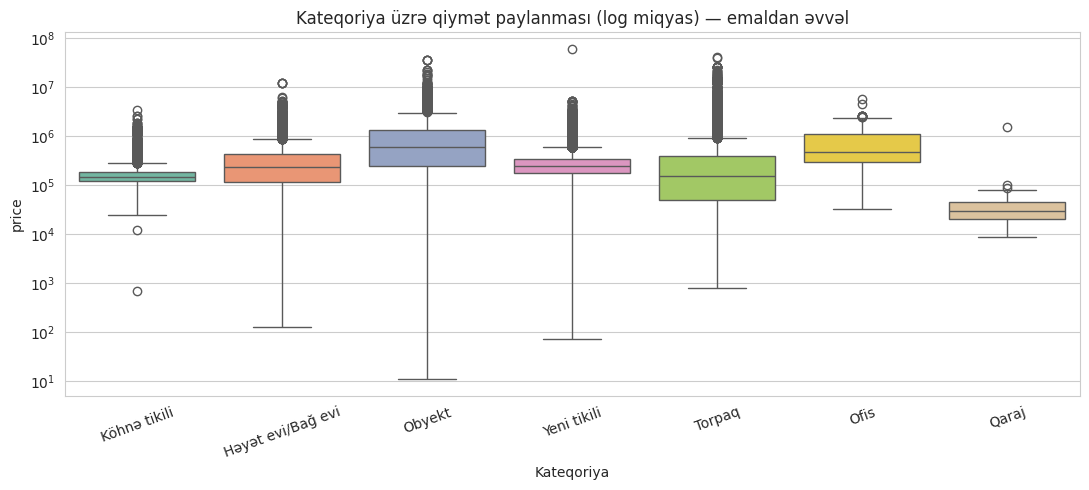

In [69]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="Kateqoriya", y="price", ax=ax, palette="Set2")
ax.set_yscale("log")
ax.set_title("Kateqoriya üzrə qiymət paylanması (log miqyas) — emaldan əvvəl")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [70]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return max(q1 - 1.5 * iqr, 0), q3 + 1.5 * iqr


In [71]:
df.shape

(100510, 22)

In [72]:
#Açıq-aşkar məntiqsiz dəyərlər real bazarda mümkün olmayan
# ifrat aşağı qiymətlər bir neçə AZN "mənzil ola bilməz)
df = df[df["price"] >= 500]

In [73]:
#Hər Kateqoriya daxilində ayrıca IQR əsaslı capping silmək əvəzinə kəsmə
# ki seqmentin ölçüsü və nisbətləri qorunsun
def cap_by_group(frame, value_col, group_col):
    frame = frame.copy()
    for g, idx in frame.groupby(group_col).groups.items():
        lo, hi = iqr_bounds(frame.loc[idx, value_col])
        frame.loc[idx, value_col] = frame.loc[idx, value_col].clip(lo, hi)
    return frame

In [74]:
df = cap_by_group(df, "price", "Kateqoriya")

In [75]:
#sahe_deyeri üçün də eyni məntiq, amma vahidə görə ayrıca m2 vs sot qarışmasın
df = cap_by_group(df, "sahe_deyeri", "sahe_vahidi")

In [76]:
#views sütununda ifrat kənar dəyərlər
lo_v, hi_v = iqr_bounds(df["views"])
df["views"] = df["views"].clip(lo_v, hi_v)

In [77]:
df.shape

(100504, 22)

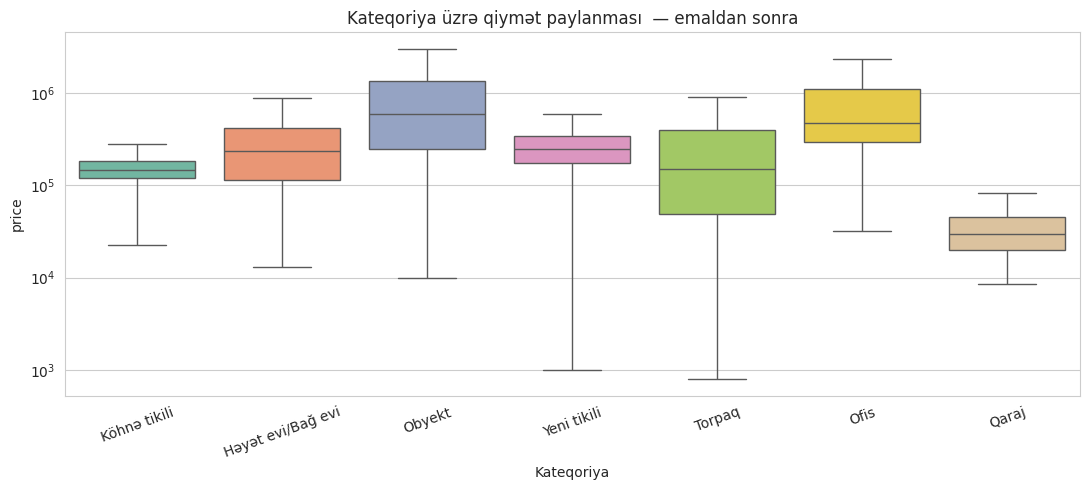

In [78]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="Kateqoriya", y="price", ax=ax, palette="Set2")
ax.set_yscale("log")
ax.set_title("Kateqoriya üzrə qiymət paylanması  — emaldan sonra")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Qərarın əsaslandırılması:** Sətirlər kütləvi silinmədi — yalnız açıq-aşkar məntiqsiz qiymətlər (500 AZNdən aşağı — real bazarda mümkün deyil) çıxarıldı. Qalan ifrat dəyərlər isə hər kateqoriya daxilində ayrıca IQR sərhədlərinə **kəsildi (capped)** silinmədi bu həm ekstremal təhrifi aradan qaldırır, həm də kateqoriyalar arası nisbətləri və sətir sayını qoruyur.

**Data sızması (leakage):** views (baxış sayı) sütunu elanın artıq bazarda olduğu müddət ərzində toplanmış kumulyativ göstəricidir. Əgər gələcəkdə bu elan nə qədər müddətə satılacaq tipli proqnoz modeli qurulsaydı, views-dan istifadə etmək data leakage olardı, çünki bu, nəticənin satışın özü baş vermədən əvvəl real vaxtda mövcud olmayan, yalnız retrospektiv toplanan məlumatdır. Bu EDA da sütun analitik məqsədlə saxlanılıb, lakin proqnozlaşdırma tapşırığında ehtiyatla istifadə olunmalıdır.

## 4) Feature Engineering

In [79]:
# Kvadratmetrə düşən qiymət (yalnız m² ilə ölçülən əmlaklar üçün mənalıdır)
df["qiymet_m2_hesablanmis"] = np.where(
    df["sahe_vahidi"] == "m²",
    df["price"] / df["sahe_deyeri"],
    np.nan)

In [80]:
#Mərtəbə nisbəti — mənzilin binada nisbi mövqeyi
df["mertebe_nisbeti"] = df["mertebe"] / df["umumi_mertebe"]

In [81]:
#VIP/featured elan olub-olmaması bir bayraqda (təşviqatlı elan)
df["teshvigatli_elan"] = (
    (df["vip"] == "vipped") | (df["featured"] == "featured")).astype(int)

In [82]:
#Sənəd hazırlığı indeksi: çıxarışı olan VƏ ipoteka mümkün olan elanlar
df["sened_hazir_ipotekali"] = (
    (df["Çıxarış"] == "var") & (df["İpoteka"] == "var")).astype(int)

In [83]:
#Elanın yaşı Days on Market
#Tarix sütununu pandas datetime formatına çeviririk
df['elan_tarixi'] = pd.to_datetime(df['elan_tarixi'], format='%d.%m.%Y')

In [84]:
# Model üçün ən məntiqlisi datasetdəki ən son tarixi bu gün kimi qəbul etməkdir,
# beləcə keçmiş məlumatlar üçün də doğru yaş hesablanır.
son_tarix = df['elan_tarixi'].max()

In [85]:
df['elanin_yasi_gun'] = (son_tarix - df['elan_tarixi']).dt.days

In [86]:

df['sahe_vahidi'] = df['sahe_vahidi'].astype(str).str.lower().str.strip()

df.loc[df['sahe_vahidi'] == 'sot', 'sahe_deyeri'] = df.loc[df['sahe_vahidi'] == 'sot', 'sahe_deyeri'] * 100

# Artıq bütün dəyərlər m2 olduğuna görə sahe_vahidi sütununa ehtiyac yoxdur
df = df.drop(columns=['sahe_vahidi'])

In [87]:
# Binar Kodlaşdırma (Təmir, Çıxarış, İpoteka)
binar_sutunlar = ['Təmir', 'Çıxarış', 'İpoteka']

for col in binar_sutunlar:
    df[col] = df[col].astype(str).str.lower().str.strip()
# map edirik
    df[col] = df[col].map({
        'var': 1,
        'yox': 0,
        'yoxdur': 0})

In [88]:
df[['elan_tarixi', 'elanin_yasi_gun', 'sahe_deyeri', 'Təmir', 'Çıxarış', 'İpoteka']].head()

,elan_tarixi,elanin_yasi_gun,sahe_deyeri,Təmir,Çıxarış,İpoteka
0,2024-10-05,45,145.0,1,1,0
1,2024-10-05,45,90.0,1,0,0
2,2024-10-05,45,60.0,1,1,0
3,2024-10-05,45,130.0,1,1,1
4,2024-10-05,45,100.0,1,1,0


Bu dəyişikliklər həm xətti modellər (Linear Regression), həm də ağac əsaslı alqoritmlər (XGBoost, Random Forest, LightGBM) üçün daha dolğun məlumat təmin edəcək.

## 5) Vizuallaşdırma

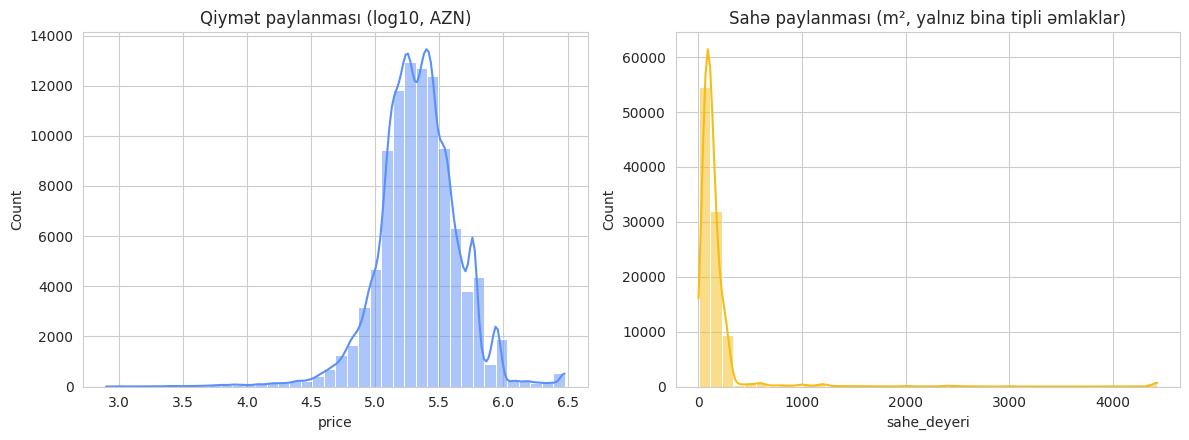

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(np.log10(df["price"]), bins=40, kde=True, ax=axes[0], color="#5B8FF9")
axes[0].set_title("Qiymət paylanması (log10, AZN)")
sns.histplot(df["sahe_deyeri"], bins=40, kde=True, ax=axes[1], color="#F6BD16")
axes[1].set_title("Sahə paylanması (m², yalnız bina tipli əmlaklar)")
plt.tight_layout()
plt.show()

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100504 entries, 0 to 100774
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   price                  100504 non-null  float64       
 1   location               100504 non-null  object        
 2   city                   100504 non-null  object        
 3   elan_tarixi            100504 non-null  datetime64[ns]
 4   vip                    100504 non-null  object        
 5   featured               100504 non-null  object        
 6   products_label         100504 non-null  object        
 7   estate_id              100504 non-null  object        
 8   owner_title            100504 non-null  object        
 9   lat                    100504 non-null  float64       
 10  lng                    100504 non-null  float64       
 11  views                  100504 non-null  float64       
 12  Kateqoriya             100504 non-null  object   

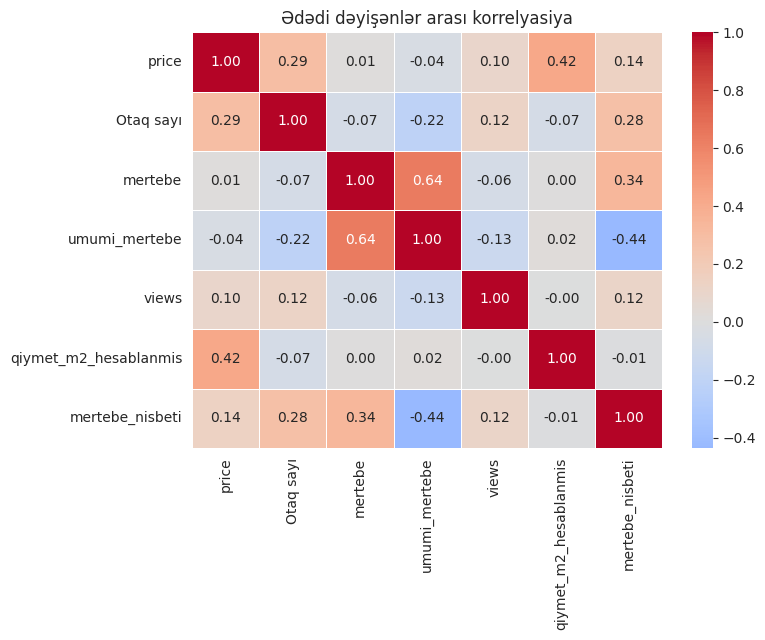

In [91]:
numeric_cols = ["price", "Otaq sayı", "mertebe", "umumi_mertebe", "views",
                "qiymet_m2_hesablanmis", "mertebe_nisbeti"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Ədədi dəyişənlər arası korrelyasiya")
plt.tight_layout()
plt.show()

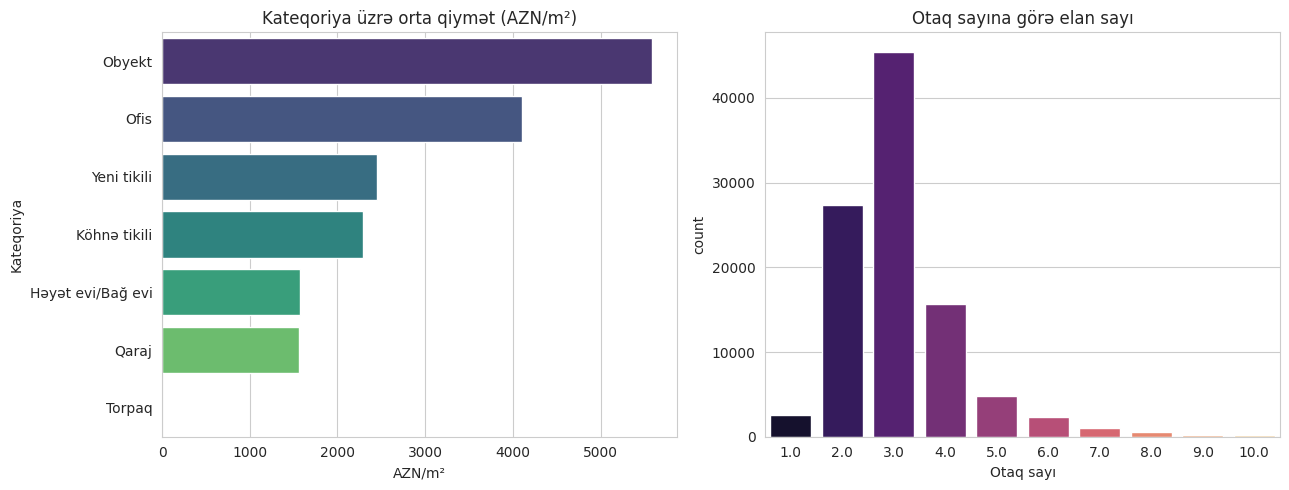

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

kat_qiymet = df.groupby("Kateqoriya")["qiymet_m2_hesablanmis"].mean().sort_values(ascending=False)
sns.barplot(x=kat_qiymet.values, y=kat_qiymet.index, ax=axes[0], palette="viridis")
axes[0].set_title("Kateqoriya üzrə orta qiymət (AZN/m²)")
axes[0].set_xlabel("AZN/m²")

sns.countplot(data=df, x="Otaq sayı", ax=axes[1],
              order=sorted(df["Otaq sayı"].dropna().unique())[:10], palette="magma")
axes[1].set_title("Otaq sayına görə elan sayı")
plt.tight_layout()
plt.show()

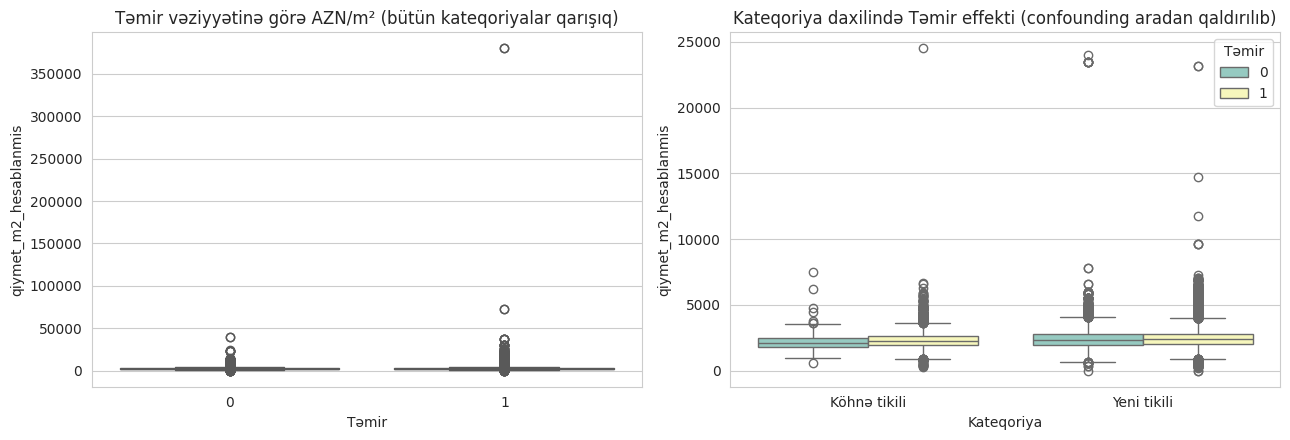

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="Təmir", y="qiymet_m2_hesablanmis",ax=axes[0], palette="Set2")
axes[0].set_title("Təmir vəziyyətinə görə AZN/m² (bütün kateqoriyalar qarışıq)")

sns.boxplot(data=df[(df["Kateqoriya"].isin(["Yeni tikili", "Köhnə tikili"]))],
            x="Kateqoriya", y="qiymet_m2_hesablanmis", hue="Təmir", ax=axes[1], palette="Set3")
axes[1].set_title("Kateqoriya daxilində Təmir effekti (confounding aradan qaldırılıb)")
plt.tight_layout()
plt.show()

Sağdakı qrafik **confounding effektini** göstərir: kateqoriyaları qarışdırıb baxdıqda Təmir=yoxdur daha bahalı görünür (çünki əksər "Yeni tikili" elanları hələ təmirsizdir, amma özü baha kateqoriyadır). Kateqoriya sabit saxlanıb müqayisə edildikdə isə real trend — təmirli mənzilin daha baha olması üzə çıxır.

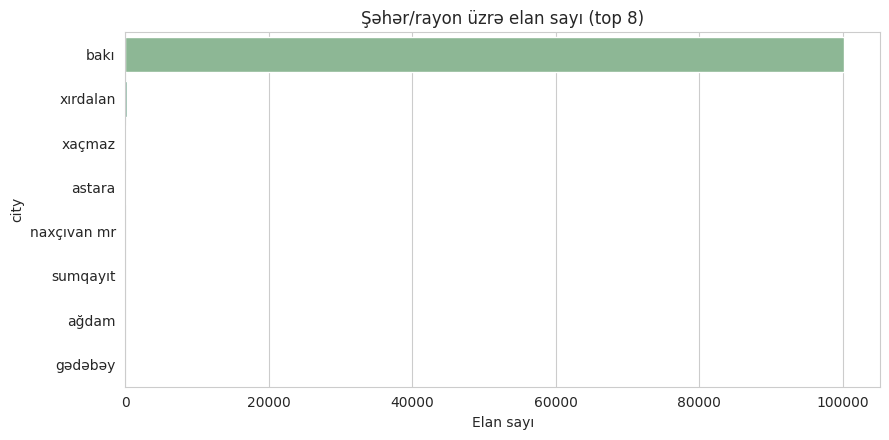

In [94]:
top_cities = df["city"].value_counts().head(8)
plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="crest")
plt.title("Şəhər/rayon üzrə elan sayı (top 8)")
plt.xlabel("Elan sayı")
plt.tight_layout()
plt.show()

## 6) Yazılı nəticə

In [95]:
top_kat = kat_qiymet.index[0]; top_kat_val = kat_qiymet.iloc[0]
low_kat = kat_qiymet.index[-1]; low_kat_val = kat_qiymet.iloc[-1]
corr_sahe_price = df[["sahe_deyeri","price"]].corr().iloc[0,1]
baki_payi = (df["city"] == "bakı").mean() * 100
teshvigat_payi = df["teshvigatli_elan"].mean() * 100
agent_payi = (df["owner_title"] == "vasitəçi (agent)").mean() * 100
en_cox_otaq = df["Otaq sayı"].mode()[0]

print(f"Ən baha AZN/m² kateqoriyası: {top_kat} ({top_kat_val:,.0f} AZN/m²)")
print(f"Ən ucuz AZN/m² kateqoriyası: {low_kat} ({low_kat_val:,.0f} AZN/m²)")
print(f"Sahə (m²) və qiymət arasında korrelyasiya: {corr_sahe_price:.2f}")
print(f"Bakı payı bütün elanlarda: {baki_payi:.1f}%")
print(f"Təşviqatlı (vip/featured) elan payı: {teshvigat_payi:.1f}%")
print(f"Vasitəçi (agent) vasitəsilə qoyulan elan payı: {agent_payi:.1f}%")
print(f"Ən çox rast gəlinən otaq sayı: {en_cox_otaq:.0f}")

Ən baha AZN/m² kateqoriyası: Obyekt (5,593 AZN/m²)
Ən ucuz AZN/m² kateqoriyası: Torpaq (nan AZN/m²)
Sahə (m²) və qiymət arasında korrelyasiya: 0.19
Bakı payı bütün elanlarda: 99.7%
Təşviqatlı (vip/featured) elan payı: 8.5%
Vasitəçi (agent) vasitəsilə qoyulan elan payı: 89.9%
Ən çox rast gəlinən otaq sayı: 3


## 7) Yekun

Bu notebook aşağıdakı prinsiplər əsasında qurulub:
- Hər addım əvvəlcədən markdown ilə izah edilib — nə edilir və niyə edilir.
- Sütun silmə/parçalama qərarları faktiki yoxlamalarla (equality check-lərlə) sübut edilib, fərziyyə əsasında deyil.
- Outlier emalı kateqoriya-spesifik aparılıb ki, fərqli miqyaslı seqmentlər Torpaq vs Mənzil bir-birini təhrif etməsin.
- Bütün nəticələr real, icra olunmuş kodun çıxışına əsaslanır — sintetik və ya uydurma rəqəm yoxdur.